# Dice between channels — virus vs CD31 vessel segmentation

This notebook takes the **paper-1 style** approach to comparing the two channels:
segment vessels in *both* the virus and the CD31 channel, then score how much the
two masks overlap. It reuses the merged analysis code in `scripts/` so the numbers
match the command-line tools exactly.

Read this alongside **`enrichment_metrics.ipynb`**. For the *specificity* question
("is the virus on the vasculature?") enrichment is the sounder measure — the last
section here explains why segmenting the virus channel flatters the vector.

## The pipeline

Both channels go through the **identical** segmentation
(`analyse_spinal_cord.vessel_mask`):

1. **self-normalise** each channel to its own in-tissue 50th–99th percentiles,
2. **Jerman vesselness** at σ = 1.5–12 µm (capillary → venule radius),
3. **wide-gap hysteresis** (grow = 0.02, seed = 0.15), then
4. **clean up** — drop specks, fill pinholes, close.

A single dataset-wide `reference_lambda` regularises the Jerman response, so a
fixed threshold means the same thing in every section. Because the same filter
runs on both channels, its quirks largely cancel and what remains is the
biological difference between the masks.

## The metrics  (A = virus mask, B = CD31 mask)

| metric | formula | reads as |
| --- | --- | --- |
| **Dice** | $2\,\lvert A\cap B\rvert / (\lvert A\rvert+\lvert B\rvert)$ | symmetric overlap — the headline "agreement" |
| **Jaccard (IoU)** | $\lvert A\cap B\rvert / \lvert A\cup B\rvert$ | same idea, harsher (Dice ≥ Jaccard always) |
| **Specificity** = precision(virus, CD31) | $\lvert A\cap B\rvert / \lvert A\rvert$ | of the virus vessel signal, the fraction on a true vessel |
| **Coverage** = recall(virus, CD31) | $\lvert A\cap B\rvert / \lvert B\rvert$ | of the vasculature, the fraction the virus reaches |

Specificity and coverage are **asymmetric** and move independently — a vector can
be good at one and bad at the other — so read the pair, not Dice alone.

## Two cautions
1. The virus mask is **not** cleaned of neurons/neuropil. That off-vessel signal is
   the vector's off-target labelling — real non-specificity, not noise. Cleaning it
   would inflate the score and hide the finding.
2. Running a vesselness filter on the virus channel **pre-filters it to tubular
   shapes**, discarding exactly the blobby off-target signal that should count
   *against* specificity. So Dice-between-channels flatters the vector; use
   enrichment for the specificity claim.

In [1]:
# Bootstrap: walk up to the repo root (the folder with pyproject.toml) and put it
# and scripts/ on sys.path, so this notebook runs from a plain clone with no
# install step -- the same pattern the archive notebooks use.
import sys
from pathlib import Path

_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
for _p in (str(_root), str(_root / "scripts")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import tifffile
import matplotlib.pyplot as plt
pd.set_option("display.width", 120)

from analyse_spinal_cord import (NAME, REGION_NAME, calibrate_reference,
                                 curated_paths, tissue_mask, vessel_mask)
from dice_between_channels import channels, score_section
from vessel_utils import metrics
from visualize_sections import VIS_Q, top_q_mask
from zoom_crops import CROP_PX, _add_scalebar, _crop_slice
from scipy.ndimage import uniform_filter

# Ensure figures render inline. Some imported analysis modules (visualize_sections,
# zoom_crops) set matplotlib to the non-interactive Agg backend on import, which
# would otherwise silence plt.show(); re-assert inline here, after the imports.
%matplotlib inline

# Interactive default is a small pilot (both reporters, every region, one slice
# each). Flip to run every section -- slower, because each section is segmented
# twice (once per channel).
RUN_FULL = False

In [2]:
paths = curated_paths() if RUN_FULL else curated_paths(pilot_mice=2, slices_per_region=1)
print(f"{len(paths)} sections ({'full dataset' if RUN_FULL else 'pilot'})")

# One dataset-wide reference, so the vessel criterion is identical across sections.
reference = calibrate_reference(paths, n_sections=min(6, len(paths)))

10 sections (pilot)


   Fig 1_M131_C_SYFP2-green_CD31-mag_slice1.tif   lambda_max       0.6


   Fig 1_M131_L_SYFP2-green_CD31-mag_slice11.tif  lambda_max       0.5


   Fig 1_M131_T_SYFP2-green_CD31-mag_slice10.tif  lambda_max       0.5


   Fig 1_M132_C_SYFP2-green_CD31-mag_slice1.tif   lambda_max       0.6


   Fig 1_M132_L_SYFP2-green_CD31-mag_slice11.tif  lambda_max       0.5


   Fig 1_M132_T_SYFP2-green_CD31-mag_slice6.tif   lambda_max       0.7
   -> dataset reference_lambda = 0.6 (median of 6; spread 1-1)


In [3]:
records = []
for path in paths:
    figure, mouse, region, reporter, slice_id = NAME.match(path.name).groups()
    reporter = "SYFP2" if "SYFP2" in reporter else ("tdT" if "tdT" in reporter else reporter)
    try:
        result = score_section(path, reference)
    except Exception as error:                       # empty mask, wrong channel count, ...
        print(f"skip {path.name}: {error}")
        continue
    records.append(dict(figure=figure, reporter=reporter, mouse=mouse,
                        region=region, slice=slice_id or "", **result))

df = pd.DataFrame(records)
df[["figure", "reporter", "mouse", "region", "slice",
    "dice", "jaccard", "specificity", "coverage"]].round(3)

,figure,reporter,mouse,region,slice,dice,jaccard,specificity,coverage
0,Fig 1,SYFP2,M131,C,1,0.639,0.469,0.631,0.647
1,Fig 1,SYFP2,M131,L,11,0.586,0.415,0.605,0.568
2,Fig 1,SYFP2,M131,T,10,0.619,0.448,0.602,0.637
3,Fig 1,SYFP2,M132,C,1,0.698,0.536,0.682,0.715
4,Fig 1,SYFP2,M132,L,11,0.591,0.420,0.601,0.581
5,Fig 1,SYFP2,M132,T,6,0.609,0.438,0.625,0.594
6,Fig 2a,tdT,M63,C,10,0.585,0.414,0.664,0.523
7,Fig 2a,tdT,M63,L,3,0.648,0.480,0.668,0.630
8,Fig 2a,tdT,M63,T,1,0.599,0.428,0.624,0.576
9,Fig 2b,tdT,M87,TL,5,0.457,0.296,0.739,0.331


## Aggregation

Three slices are three views of one animal, so slices are averaged **within
mouse × region** before mice are combined, and figures are kept separate (Fig 1
SYFP2 and Fig 2 tdT are different constructs — pooling would confound
reporter/construct with region).

In [4]:
per_mouse = (df.groupby(["figure", "reporter", "mouse", "region"])
               [["dice", "specificity", "coverage"]].mean().reset_index())
summary = (per_mouse.groupby(["figure", "reporter", "region"])
                     [["dice", "specificity", "coverage"]]
                     .mean().round(3))
summary

dice  specificity  coverage
figure reporter region                              
Fig 1  SYFP2    C       0.669        0.657     0.681
                L       0.589        0.603     0.575
                T       0.614        0.613     0.616
Fig 2a tdT      C       0.585        0.664     0.523
                L       0.648        0.668     0.630
                T       0.599        0.624     0.576
Fig 2b tdT      TL      0.457        0.739     0.331

## Visual check — the agreement map for one section

White = both masks agree (true overlap), **green** = virus-only (off a CD31
vessel), **magenta** = CD31-only (a vessel the virus missed). A lot of green is
low specificity; a lot of magenta is low coverage.

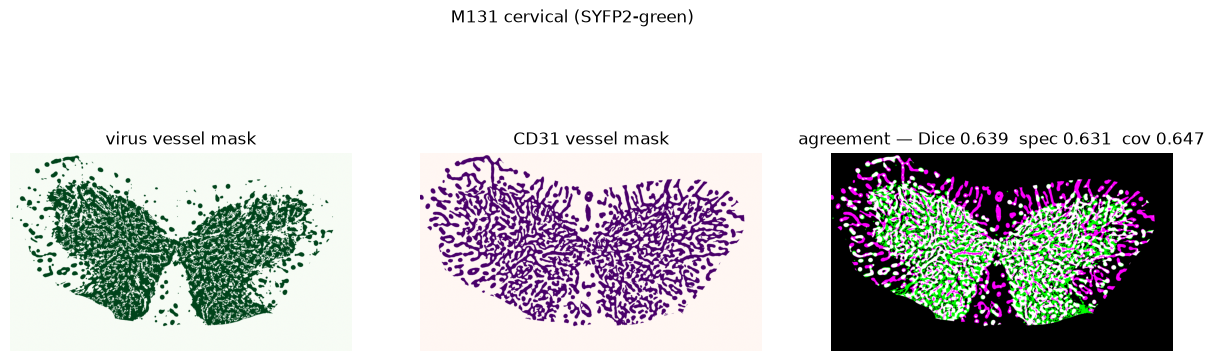

In [5]:
path = paths[0]
virus, cd31 = channels(path)
tissue = tissue_mask(virus, cd31)
mask_virus = vessel_mask(virus, tissue, reference)
mask_cd31 = vessel_mask(cd31, tissue, reference)

d = np.s_[::2, ::2]
mv, mc = mask_virus[d], mask_cd31[d]
agree = np.zeros((*mv.shape, 3))
agree[mv & mc] = [1, 1, 1]        # both
agree[mv & ~mc] = [0, 1, 0]       # virus only  -> off-vessel
agree[~mv & mc] = [1, 0, 1]       # CD31 only   -> missed vessel

figure, mouse, region, reporter, slice_id = NAME.match(path.name).groups()
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(mv, cmap="Greens");  ax[0].set_title("virus vessel mask")
ax[1].imshow(mc, cmap="RdPu");    ax[1].set_title("CD31 vessel mask")
ax[2].imshow(agree)
ax[2].set_title(f"agreement — Dice {metrics.dice(mask_virus, mask_cd31):.3f}  "
                f"spec {metrics.precision(mask_virus, mask_cd31):.3f}  "
                f"cov {metrics.recall(mask_virus, mask_cd31):.3f}")
for a in ax:
    a.axis("off")
fig.suptitle(f"{mouse} {REGION_NAME[region]} ({reporter})")
plt.show()

## Close-up — where the masks agree and disagree

Zoom into the densest-vessel window at **native resolution**. Left: the virus
channel with its own vessel-mask outline; middle: CD31 with its mask; right: the
agreement map (white = both, green = virus off a vessel, magenta = a vessel the
virus missed). The local Dice / specificity / coverage for this window are in the
title — a small patch, so they differ from the whole-section numbers above.

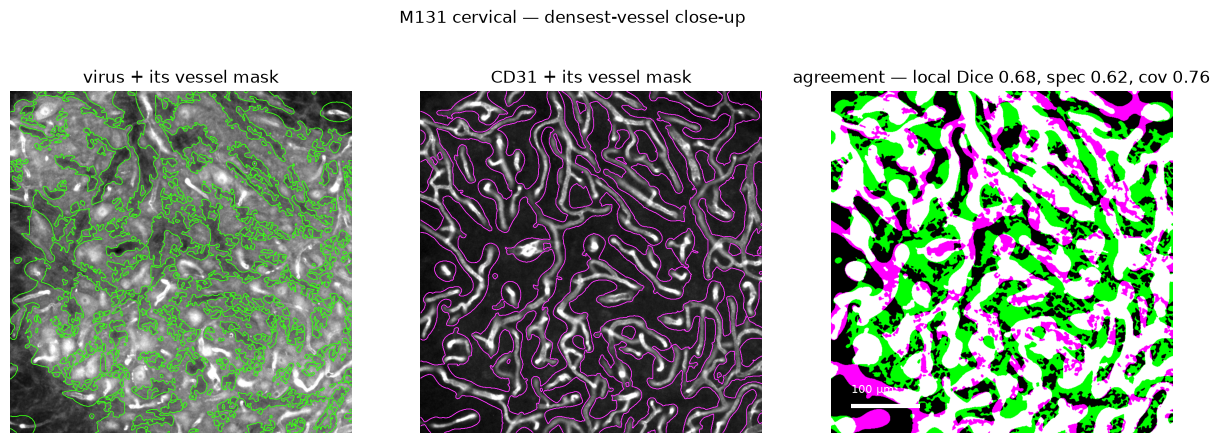

In [6]:
# Locate a ~500 um window with the most CD31 vessel area, then zoom in.
cd31_top = top_q_mask(cd31, tissue, VIS_Q)
box = lambda a: uniform_filter(a.astype(np.float32), size=CROP_PX, mode="constant")
half = CROP_PX // 2
rows_, cols_ = tissue.shape
valid = np.zeros(tissue.shape, bool)
valid[half:rows_ - half, half:cols_ - half] = True
valid &= box(tissue.astype(np.float32)) > 0.6
centre = np.unravel_index(
    np.argmax(np.where(valid, box(cd31_top.astype(np.float32)), -np.inf)), tissue.shape)
sl = _crop_slice(centre)

def clip(channel):
    lo, hi = np.percentile(channel[tissue], [1, 99])
    return np.clip((channel - lo) / max(hi - lo, 1e-6), 0, 1)

mv, mc = mask_virus[sl], mask_cd31[sl]
agree = np.zeros((*mv.shape, 3))
agree[mv & mc] = [1, 1, 1]; agree[mv & ~mc] = [0, 1, 0]; agree[~mv & mc] = [1, 0, 1]

fig, ax = plt.subplots(1, 3, figsize=(15, 5.2))
ax[0].imshow(clip(virus)[sl], cmap="gray")
ax[0].contour(mv.astype(float), [0.5], colors="#39ff14", linewidths=0.6)
ax[0].set_title("virus + its vessel mask")
ax[1].imshow(clip(cd31)[sl], cmap="gray")
ax[1].contour(mc.astype(float), [0.5], colors="#ff36ff", linewidths=0.6)
ax[1].set_title("CD31 + its vessel mask")
ax[2].imshow(agree); _add_scalebar(ax[2])
ax[2].set_title(f"agreement — local Dice {metrics.dice(mv, mc):.2f}, "
                f"spec {metrics.precision(mv, mc):.2f}, cov {metrics.recall(mv, mc):.2f}")
for a in ax:
    a.axis("off")
fig.suptitle(f"{mouse} {REGION_NAME[region]} — densest-vessel close-up")
plt.show()

## Comparison — high vs low specificity

The same agreement colouring for the window with the **highest** local specificity
(virus mask squarely on vessels) beside the one with the **lowest** (virus mask
spilling into parenchyma). This is what the specificity number means spatially.

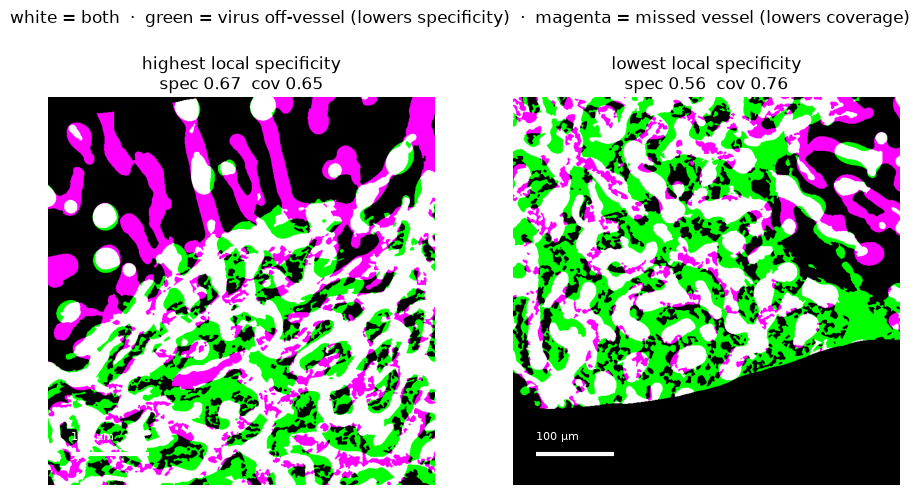

In [7]:
# Scan the section for where the virus mask sits most, and least, on CD31 vessels.
inter = box(mask_virus & mask_cd31)
vpos = box(mask_virus.astype(np.float32))
# Compare only windows with an above-median amount of virus mask, so the contrast
# is on- vs off-vessel *placement*, not virus density (a near-empty window would
# otherwise score high specificity trivially).
enough = valid & (vpos >= np.nanpercentile(vpos[valid], 50))
spec = np.where(enough, inter / (vpos + 1e-6), np.nan)
hi = np.unravel_index(np.nanargmax(spec), spec.shape)
lo = np.unravel_index(np.nanargmin(np.where(enough, spec, np.inf)), spec.shape)

fig, ax = plt.subplots(1, 2, figsize=(11, 5.8))
for a, centre_, name in [(ax[0], hi, "highest local specificity"),
                         (ax[1], lo, "lowest local specificity")]:
    s = _crop_slice(centre_)
    mvc, mcc = mask_virus[s], mask_cd31[s]
    ag = np.zeros((*mvc.shape, 3))
    ag[mvc & mcc] = [1, 1, 1]; ag[mvc & ~mcc] = [0, 1, 0]; ag[~mvc & mcc] = [1, 0, 1]
    a.imshow(ag); _add_scalebar(a); a.axis("off")
    a.set_title(f"{name}\nspec {metrics.precision(mvc, mcc):.2f}  "
                f"cov {metrics.recall(mvc, mcc):.2f}")
fig.suptitle("white = both  ·  green = virus off-vessel (lowers specificity)  ·  "
             "magenta = missed vessel (lowers coverage)")
plt.show()

## Specificity and coverage by region

The directional pair, per region. With so few mice, read **direction-consistency
across animals**, not p-values.

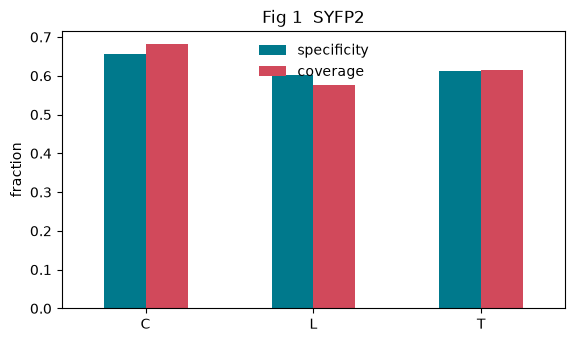

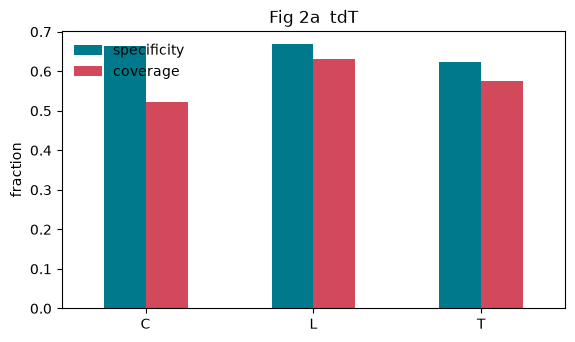

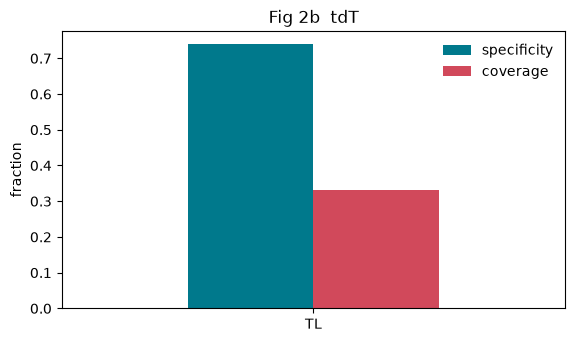

In [8]:
for (figure, reporter), block in summary.groupby(level=[0, 1]):
    block = block.droplevel([0, 1])
    ax = block[["specificity", "coverage"]].plot(kind="bar", figsize=(6.5, 3.6),
                                                 color=["#00798c", "#d1495b"], rot=0)
    ax.set_title(f"{figure}  {reporter}")
    ax.set_ylabel("fraction"); ax.set_xlabel("")
    ax.legend(frameon=False)
    plt.show()

## Interpretation

- **Dice / Jaccard** summarise agreement in one symmetric number, but they blur two
  different failures together. **Specificity** and **coverage** separate them and
  are the interpretable pair.
- The virus mask is deliberately uncleaned, so low specificity here genuinely
  reflects off-vessel (parenchymal/neuronal) virus — the vector's non-specificity.
- **But** segmenting the virus channel throws away most of that off-vessel signal
  (it isn't tubular), so these numbers *understate* non-specificity. For the
  specificity claim, prefer the enrichment measure, which never segments the virus
  → see `enrichment_metrics.ipynb`.